# 👩‍💻 Loan Approval Prediction with Logistic Regression

## 📋 Overview
In this lab, you'll utilize logistic regression to predict loan approvals based on applicants' financial information. This hands-on experience will help you understand data preprocessing, model training, and result evaluation using key classification metrics. By working with a loan approval dataset, you'll gain practical experience implementing a binary classification model that has direct applications in real-world financial decision-making.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Preprocess financial data for machine learning applications
- Implement logistic regression for binary classification problems
- Evaluate classification model performance using multiple metrics
- Visualize and interpret classification results
- Apply machine learning techniques to solve financial industry problems

## Task 1: Load and Explore the Dataset
**Context:** Financial analysts need to first understand the data they're working with before building predictive models.

**Steps:**

1. Import the necessary libraries (pandas, sklearn, matplotlib, seaborn)
2. Download the loan approval dataset using the provided curl command
3. Load the 'loan_data.csv' dataset using pandas
4. Display the first 5 rows to understand the structure
5. Generate summary statistics to understand feature distributions
6. Check for missing values in the dataset


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('loan_data.csv')

# Your code for exploration goes here
# Hint: Use data.head(), data.describe(), and data.isnull().sum()
print(data.shape)
data.head(2)

(45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0


In [2]:
data.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

**💡 Tip:** Pay special attention to the target variable ('loan_status') distribution to understand if the dataset is balanced or imbalanced.

**⚙️ Test Your Work:**

- Verify that the dataset is correctly loaded and displays information about applicants and loan approval status
- Confirm you can see the data types and missing value counts


## Task 2: Data Preparation and Preprocessing
**Context:** Raw financial data often needs cleaning and transformation before modeling to ensure accurate predictions.

**Steps:**

1. Handle missing values using forward fill method
2. Select relevant features for predicting loan approval
3. Normalize the numerical features to ensure consistent scaling
4. Create your feature matrix (X) and target vector (y)
5. Split the data into training (80%) and testing (20%) sets using a fixed random state

**💡 Tip:** Consider the correlation between features and the target variable when selecting which features to include in your model.

In [3]:
# Handle missing values
# Your code here
data = data.fillna(method='ffill')

# Feature selection - we'll use these three key features
X = data[['person_income', 'credit_score', 'loan_amnt']]
y = data['loan_status']

# Splitting data into training and test sets
# Your code here - use test_size=0.2 and random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data normalization
# Your code here
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
print("Missing values:", '\n', data.isnull().sum().sum())  # Should be 0

print("Train mean:", np.mean(X_train_scaled, axis=0))
print("Train std:", np.std(X_train_scaled, axis=0))

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Total size:", len(data))

Missing values: 
 0
Train mean: [-7.53964792e-17 -6.52367049e-16  1.08160394e-16]
Train std: [1. 1. 1.]
Train size: 36000
Test size: 9000
Total size: 45000


**⚙️ Test Your Work:**

- Verify that there are no missing values in your processed dataset
- Confirm that your features are properly scaled (mean close to 0, std close to 1)
- Check that your train/test split has the expected proportions

## Task 3: Model Training and Prediction
**Context:** Financial institutions use classification models to automate the initial loan approval process evaluation.

**Steps:**

1. Initialize a LogisticRegression model with max_iter=100
2. Fit the model using your training data
3. Generate predictions for the test dataset

In [5]:
# Training logistic regression model
model = LogisticRegression(max_iter=100)

# Your code to fit the model here
model.fit(X_train_scaled, y_train)

# Making predictions
# Your code here
y_pred = model.predict(X_test_scaled)

**💡 Tip:** If convergence warnings occur, try increasing max_iter or adjusting the regularization parameter.

**⚙️ Test Your Work:**

- Confirm that the model training completes without errors
- Verify that predictions are binary values matching the target variable format

## Task 4: Model Evaluation
**Context:** Before deploying a loan approval model, banks must thoroughly evaluate its performance to ensure fair and accurate decisions.

**Steps:**

1. Calculate accuracy, precision, and recall scores
2. Generate and visualize a confusion matrix
3. Create an ROC curve and calculate the AUC score

Accuracy: 0.79
Precision: 0.67
Recall: 0.12


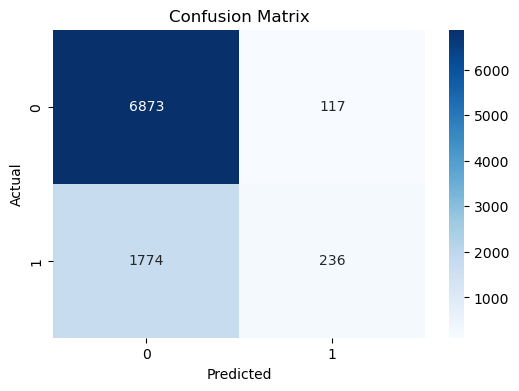

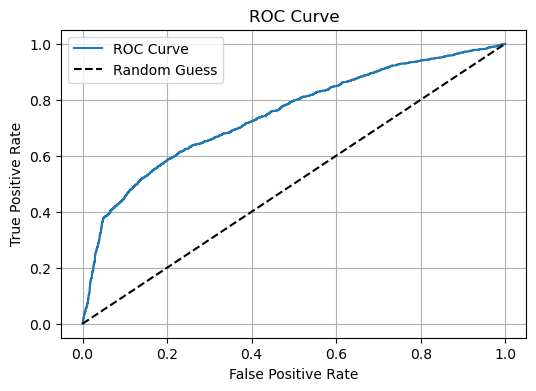

AUC Score: 0.75


In [6]:
# Evaluating model performance
# Your code for accuracy, precision and recall here
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

# Confusion Matrix
# Your code here

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# ROC Curve
from sklearn.metrics import roc_curve

# Your code here to create the ROC curve

from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# AUC Score
from sklearn.metrics import roc_auc_score

# Your code here to determine the AUC score

auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc:.2f}")

**💡 Tip:** In loan approval scenarios, consider which is more costly: falsely approving a bad loan or rejecting a good loan application.

**⚙️ Test Your Work:**

- Examine your metrics to ensure they're within a reasonable range
- Verify that your confusion matrix and ROC curve display correctly

## ✅ Success Checklist
- Dataset is successfully loaded and explored
- Missing values are properly handled
- Features are correctly normalized
- Data is appropriately split into training and testing sets
- Logistic regression model is properly trained
- Predictions are generated on the test set
- Multiple evaluation metrics are calculated and interpreted
- Visualizations effectively show the confusion matrix and ROC curve
- All code runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Dataset download fails 
- **Solution:** Ensure you have internet connectivity or download the dataset manually from Kaggle

**Problem:** Missing values cause errors in model training 
- **Solution:** Verify that all missing values are handled with data.fillna() before training

**Problem:** "ConvergenceWarning" appears during model training 
- **Solution:** Increase the max_iter parameter (e.g., to 1000) or normalize your features if not already done

## 🔑 Key Points
- Logistic regression is well-suited for binary classification problems like loan approval
- Proper data preprocessing (handling missing values, normalization) is crucial for model performance
- Multiple evaluation metrics provide a comprehensive view of model performance
- Visualizations help communicate model results effectively to stakeholders


## Exemplar Solution
After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches.
Reflect on what you can learn from the exemplar solution to improve your coding skills.
Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.
Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.


<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('loan_data.csv')

# Data Exploration
print(data.head())
print(data.describe())
print(data.isnull().sum())

# Data Cleaning
data.fillna(method='ffill', inplace=True)

# Feature selection based on domain knowledge or exploratory analysis
X = data[['person_income', 'credit_score', 'loan_amnt']]
y = data['loan_status']

# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data normalization
mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std


# Training logistic regression model
model = LogisticRegression(max_iter=100)
model.fit(X_train_scaled, y_train) # Use scaled training data

# Making predictions
y_pred = model.predict(X_test_scaled) # Use scaled test data
y_prob = model.predict_proba(X_test_scaled)[:, 1] # Use scaled test data for probabilities


# Evaluating model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"AUC Score: {auc_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

    
    
```    